# EDA Análisis exploratorio de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv")
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


## Exploracion y limpieza

In [3]:
df.shape

(3140, 108)

In [4]:
df. info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [5]:
df = df.drop_duplicates().reset_index(drop = True)
df = df.dropna()
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [6]:
df.shape

(3140, 108)

In [7]:
df.columns.tolist()

['fips',
 'TOT_POP',
 '0-9',
 '0-9 y/o % of total pop',
 '19-Oct',
 '10-19 y/o % of total pop',
 '20-29',
 '20-29 y/o % of total pop',
 '30-39',
 '30-39 y/o % of total pop',
 '40-49',
 '40-49 y/o % of total pop',
 '50-59',
 '50-59 y/o % of total pop',
 '60-69',
 '60-69 y/o % of total pop',
 '70-79',
 '70-79 y/o % of total pop',
 '80+',
 '80+ y/o % of total pop',
 'White-alone pop',
 '% White-alone',
 'Black-alone pop',
 '% Black-alone',
 'Native American/American Indian-alone pop',
 '% NA/AI-alone',
 'Asian-alone pop',
 '% Asian-alone',
 'Hawaiian/Pacific Islander-alone pop',
 '% Hawaiian/PI-alone',
 'Two or more races pop',
 '% Two or more races',
 'POP_ESTIMATE_2018',
 'N_POP_CHG_2018',
 'GQ_ESTIMATES_2018',
 'R_birth_2018',
 'R_death_2018',
 'R_NATURAL_INC_2018',
 'R_INTERNATIONAL_MIG_2018',
 'R_DOMESTIC_MIG_2018',
 'R_NET_MIG_2018',
 'Less than a high school diploma 2014-18',
 'High school diploma only 2014-18',
 "Some college or associate's degree 2014-18",
 "Bachelor's degree or 

In [8]:
target = "Heart disease_prevalence"

df_ml = df.drop(columns=["fips", "COUNTY_NAME", "STATE_NAME", "STATE_FIPS", "CNTY_FIPS", "Urban_rural_code"])

In [9]:
print(f"Dataset listo. Total de columnas: {len(df_ml.columns)}")
df_ml.head()

Dataset listo. Total de columnas: 102


,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,...,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number
0,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,...,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326
1,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,...,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479
2,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,...,13.3,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887
3,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,3038,...,11.3,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595
4,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,7474,...,12.0,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507


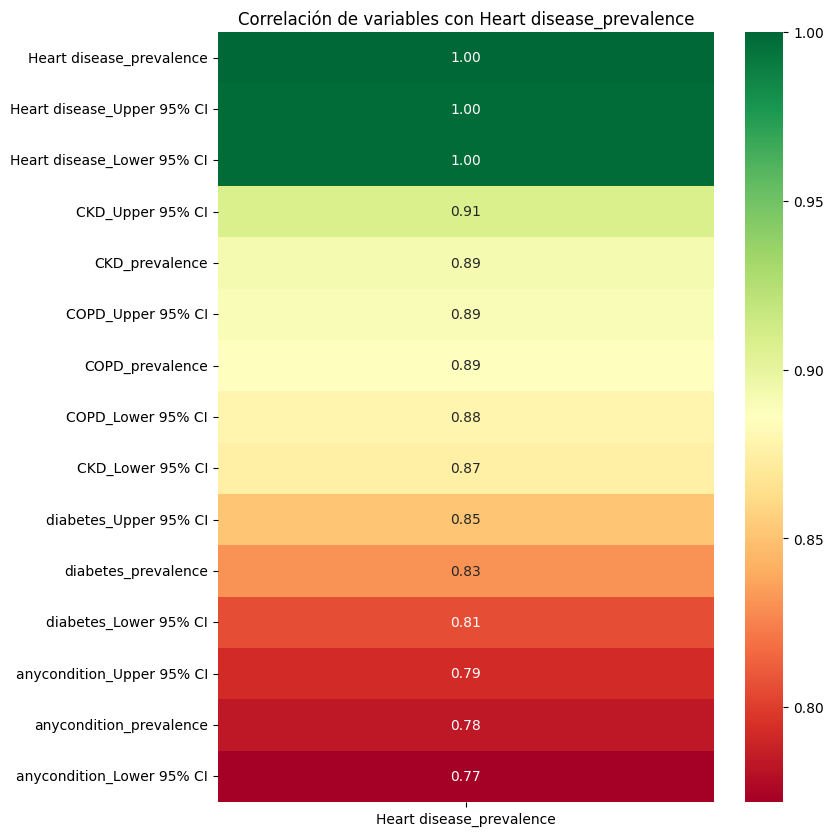

In [10]:
# Calculamos la matriz de correlación
corr_matrix = df_ml.corr()

# Filtramos para ver solo la relación con el target (ordenada)
target_corr = corr_matrix[[target]].sort_values(by=target, ascending=False)

# Dibujamos un Heatmap de las top 15 variables más relacionadas
plt.figure(figsize=(8, 10))
sns.heatmap(target_corr.head(15), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title(f"Correlación de variables con {target}")
plt.show()

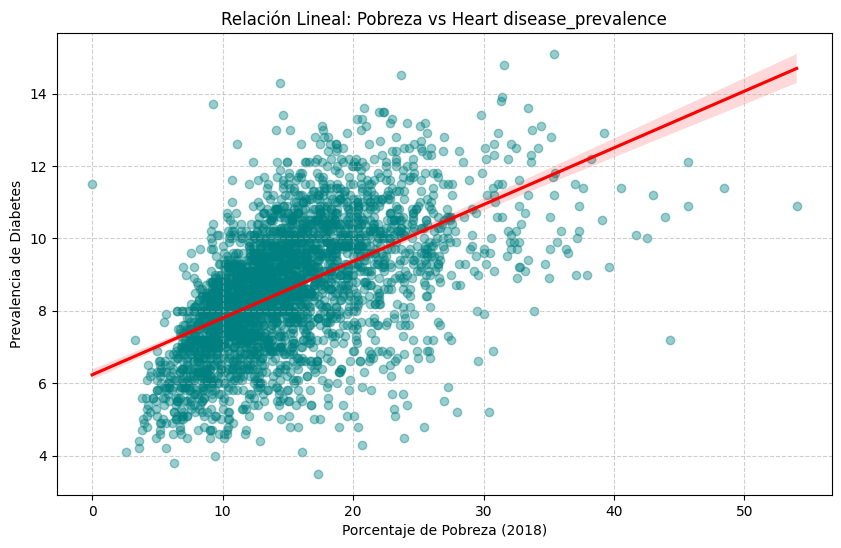

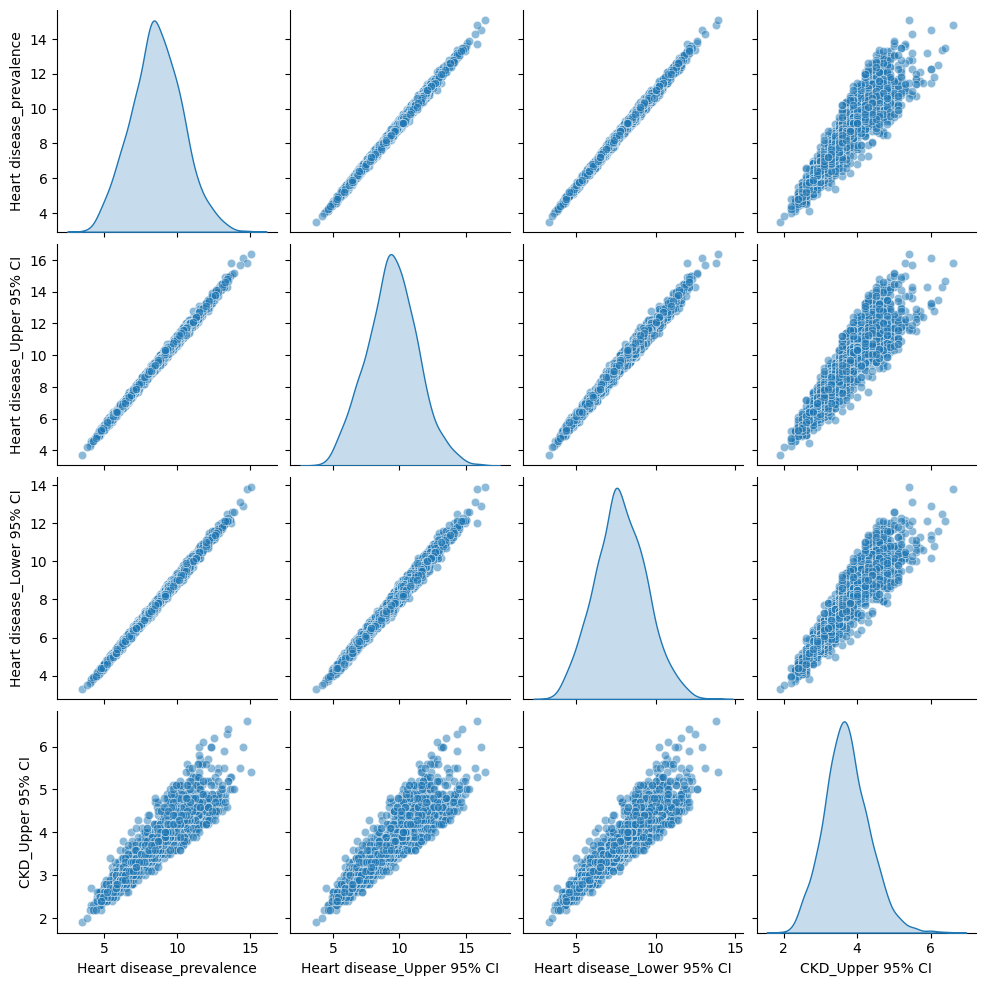

In [11]:
# Elegimos una variable con alta correlación según la matriz
top_feature = "PCTPOVALL_2018" # Porcentaje de pobreza total

plt.figure(figsize=(10, 6))
sns.regplot(data=df_ml, x=top_feature, y=target, 
            scatter_kws={"alpha":0.4, "color":"teal"}, 
            line_kws={"color":"red"})

plt.title(f"Relación Lineal: Pobreza vs {target}")
plt.xlabel("Porcentaje de Pobreza (2018)")
plt.ylabel("Prevalencia de Diabetes")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Seleccionamos el target y las 3 variables más correlacionadas
top_3_vars = target_corr.head(4).index.tolist()

sns.pairplot(df_ml[top_3_vars], diag_kind="kde", plot_kws={"alpha": 0.5})
plt.show()

In [13]:
# División en Train y Test
X = df_ml.drop(columns=[target])
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Guardar splits
pd.concat([X_train, y_train], axis=1).to_csv("../data/processed/train_data.csv", index=False)
pd.concat([X_test, y_test], axis=1).to_csv("../data/processed/test_data.csv", index=False)

# Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Regresión Lineal Base 
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_base = lr.predict(X_test_scaled)
r2_base = r2_score(y_test, y_pred_base)
print(f"R2 Regresión Lineal Base: {r2_base:.4f}")

R2 Regresión Lineal Base: 0.9995


In [20]:
# Modelo Lasso con Barrido de Alpha 
alphas = np.linspace(0.01, 20, 50)
r2_lasso_results = []

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_train_scaled, y_train)
    r2_lasso_results.append(r2_score(y_test, lasso.predict(X_test_scaled)))

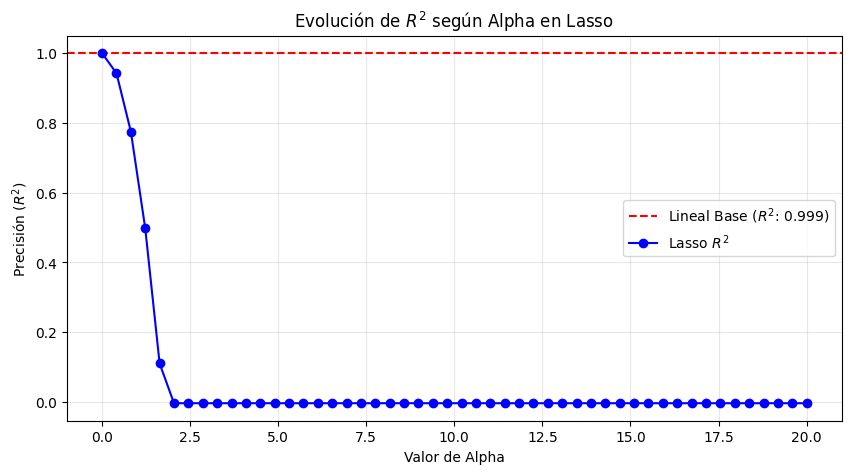

In [21]:
#  Visualización de la evolución de R2 
plt.figure(figsize=(10, 5))
plt.axhline(y=r2_base, color='red', linestyle='--', label=f'Lineal Base ($R^2$: {r2_base:.3f})')
plt.plot(alphas, r2_lasso_results, label='Lasso $R^2$', color='blue', marker='o')
plt.title('Evolución de $R^2$ según Alpha en Lasso')
plt.xlabel('Valor de Alpha')
plt.ylabel('Precisión ($R^2$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# Probaremos con un modelo Ridge para ver si mejora a Lasso
r2_ridge_results = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    r2_ridge_results.append(r2_score(y_test, ridge.predict(X_test_scaled)))

best_alpha_lasso = alphas[np.argmax(r2_lasso_results)]
best_alpha_ridge = alphas[np.argmax(r2_ridge_results)]

print(f"\n--- RESUMEN DE OPTIMIZACIÓN ---")
print(f"Mejor Alpha Lasso: {best_alpha_lasso:.2f} (R2: {max(r2_lasso_results):.4f})")
print(f"Mejor Alpha Ridge: {best_alpha_ridge:.2f} (R2: {max(r2_ridge_results):.4f})")


--- RESUMEN DE OPTIMIZACIÓN ---
Mejor Alpha Lasso: 0.01 (R2: 0.9994)
Mejor Alpha Ridge: 0.01 (R2: 0.9995)


In [23]:
# Modelo Final (Elegimos el mejor de los dos)
if max(r2_lasso_results) > max(r2_ridge_results):
    final_model = Lasso(alpha=best_alpha_lasso)
    print("El modelo ganador es: LASSO")
else:
    final_model = Ridge(alpha=best_alpha_ridge)
    print("El modelo ganador es: RIDGE")

final_model.fit(X_train_scaled, y_train)

El modelo ganador es: RIDGE


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",np.float64(0.01)
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Grad